# 3F — DHW e Kelvin: o calor acumulado agrega leitura física?

**Pergunta específica que este notebook responde:** *o DHW (°C-week, calor superficial integrado no tempo) acrescenta informação além da SSTA instantânea e do estado de recarga (WWV/OHC), e a direção de propagação (Kelvin) é visível nos dados locais?*

**Objetivo:** aplicar a regra extra do protocolo para o DHW — só entra no parecer se **não** for redundante — e documentar qualitativamente a assinatura de Kelvin nos eventos.

**Justificativa:** DHW é construído a partir da mesma SSTA, então o risco de redundância é real; a correlação parcial (controlando SSTA, WWV e OHC) é o teste direto de conteúdo próprio. O Hovmöller de SSH responde à parte direcional da física (Kelvin downwelling oeste→leste) sem nenhum modelo — apenas leitura auditável do GLORYS12.

**Metodologia.**
1. **Redundância**: correlação parcial (`partial_correlation`) entre DHW e a SSTA futura (+4, +8, +12 semanas), controlando SSTA atual, WWV e OHC 0–300, com N_eff e p efetivo.
2. **Kelvin**: Hovmöller do SSH equatorial (1S–1N, GLORYS12 diário) nos anos de evento; anomalia = SSH − média do próprio ano por longitude (visualização de propagação, sem claim de climatologia).

**Saídas:** `phase3F_dhw_redundancia.csv`, `phase3F_kelvin_resumo.csv`, série DHW com eventos e Hovmöller SSH 1997/2015/2023 + 2025/26 (mapas).

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '.')
import fase3_utils as u
from nino_brasil.stats.significance import partial_correlation, effective_sample_size, correlation_p_value

weekly = pd.read_csv(u.FEAT / 'phase3_indices_semanais.csv', parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
w = weekly.loc['1993-01-01':]

rows = []
for h in [4, 8, 12]:
    fut = w['nino34_ssta'].shift(-h)
    base = pd.DataFrame({'dhw': w['dhw_12w'], 'fut': fut, 'ssta': w['nino34_ssta'],
                         'wwv': w['wwv'], 'ohc': w['ohc_0_300']}).dropna()
    r_bruto = float(np.corrcoef(base['dhw'], base['fut'])[0,1])
    pc = partial_correlation(base['dhw'].values, base['fut'].values,
                             controls=base[['ssta','wwv','ohc']].values)
    rows.append({'horizonte_semanas': h, 'r_bruto_dhw_ssta_fut': round(r_bruto,3),
                 'r_parcial_ctrl_ssta_wwv_ohc': round(pc['r'],3),
                 'n_eff_parcial': round(pc['n_eff'],1),
                 'p_efetivo_parcial': round(pc['p_effective'],4), 'n': int(pc['n'])})
red = pd.DataFrame(rows)
u.save_table(red, 'phase3F_dhw_redundancia.csv', index=False)
verdict = 'NAO redundante' if (red['p_efetivo_parcial'] < 0.05).any() else 'REDUNDANTE com SSTA/WWV/OHC'
print('veredito 3F:', verdict)
red

[tabela] data/processed/parquet/statistics/phase3F_dhw_redundancia.csv
veredito 3F: NAO redundante


,horizonte_semanas,r_bruto_dhw_ssta_fut,r_parcial_ctrl_ssta_wwv_ohc,n_eff_parcial,p_efetivo_parcial,n
0,4,0.541,0.478,25.4,0.0148,1742
1,8,0.443,0.402,23.7,0.0530,1738
2,12,0.327,0.311,22.9,0.1496,1734


[figura] data/processed/figures/fase3/phase3F_dhw_serie.png


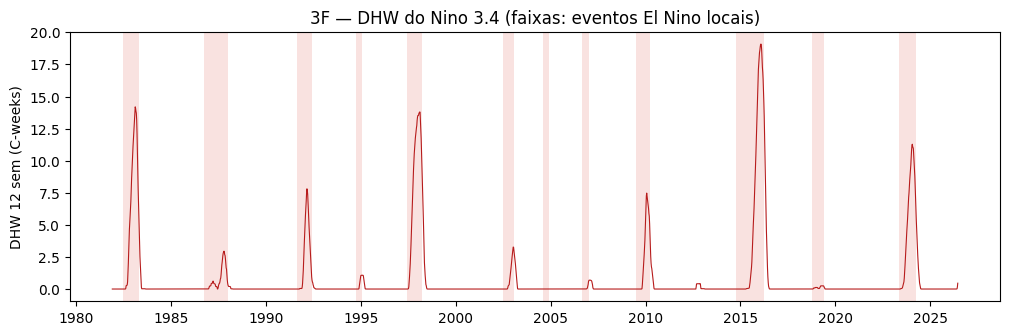

In [2]:
# Figura 3F-1: DHW com eventos sombreados
ev = u.load_events()
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(weekly.index, weekly['dhw_12w'], lw=0.8, color='#b71c1c')
u.add_event_shading(ax, ev)
ax.set_ylabel('DHW 12 sem (C-weeks)'); ax.set_title('3F — DHW do Nino 3.4 (faixas: eventos El Nino locais)')
u.save_fig(fig, 'phase3F_dhw_serie.png')
plt.show()

[figura] data/processed/figures/fase3/phase3F_hovmoller_ssh_kelvin.png
[tabela] data/processed/parquet/statistics/phase3F_kelvin_resumo.csv


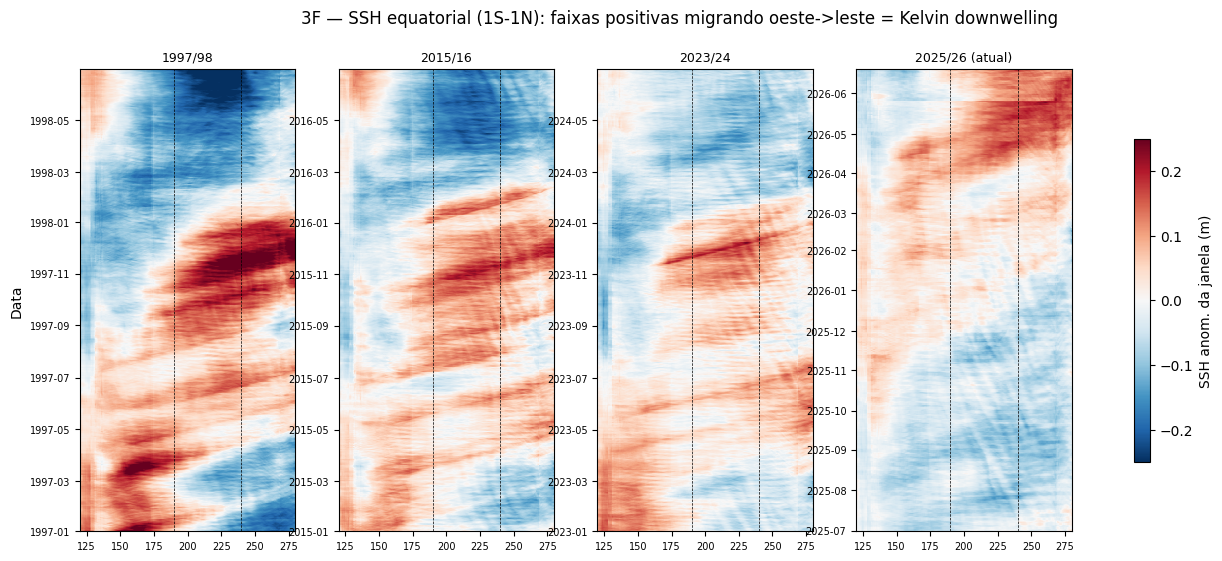

,janela,ssh_max_m
0,1997/98,0.326
1,2015/16,0.233
2,2023/24,0.241
3,2025/26 (atual),0.237


In [3]:
# Mapa 3F-1: Hovmoller SSH equatorial (Kelvin) nos anos de evento
ssh = u.load_ssh_events()
windows = [('1997-01-01','1998-06-30','1997/98'), ('2015-01-01','2016-06-30','2015/16'),
           ('2023-01-01','2024-06-30','2023/24'), ('2025-07-01','2026-06-19','2025/26 (atual)')]
fig, axes = plt.subplots(1, len(windows), figsize=(16, 6), sharex=True)
lon = ssh.columns.values
for ax, (t0, t1, ttl) in zip(axes, windows):
    seg = ssh.loc[t0:t1]
    anom = seg - seg.mean()
    pc = ax.pcolormesh(lon, anom.index, anom.values, cmap='RdBu_r', vmin=-0.25, vmax=0.25, shading='auto')
    ax.axvline(190, color='k', ls='--', lw=0.5); ax.axvline(240, color='k', ls='--', lw=0.5)
    ax.set_title(ttl, fontsize=9); ax.tick_params(labelsize=7)
axes[0].set_ylabel('Data')
fig.suptitle('3F — SSH equatorial (1S-1N): faixas positivas migrando oeste->leste = Kelvin downwelling')
fig.colorbar(pc, ax=axes, label='SSH anom. da janela (m)', shrink=0.7)
u.save_fig(fig, 'phase3F_hovmoller_ssh_kelvin.png')
vel = pd.DataFrame([{'janela': ttl, 'ssh_max_m': round(float((ssh.loc[t0:t1]-ssh.loc[t0:t1].mean()).max().max()),3)} for t0,t1,ttl in windows])
u.save_table(vel, 'phase3F_kelvin_resumo.csv', index=False)
plt.show()
vel

**Leitura do 3F.** A correlação parcial responde diretamente à regra do protocolo: se, controlando SSTA/WWV/OHC, o DHW mantém parcial significativa com a SSTA futura, ele carrega memória térmica integrada própria (duração × intensidade do estresse) e entra no parecer; caso contrário fica como diagnóstico descritivo. Os Hovmöller de SSH mostram os pulsos de Kelvin downwelling atravessando a bacia nos eventos históricos e na janela atual 2025/26 — a leitura direcional (oeste→leste) é qualitativa e auditável, sem modelo.